# Heavy Water Moderated Reactor Model

This notebook implements a heavy water (D2O) moderated MSR system using the msrDynamics library.
The system models:
- Core with fuel and coolant channels
- Heavy water (D2O) moderator cooling
- Water (H2O) cooling loop for the heavy water

In [1]:
from jitcdde import t
from toyParameters import *
import numpy as np
import matplotlib.pyplot as plt
from msrDynamics import Node, System

## Instantiate System and Nodes

In [2]:
# Create the system
reactor = System()

# ============ CORE NODES ============
# Fuel nodes (split into two for inlet/outlet)
c_f1 = Node(m=m_f_c/2, scp=scp_f, W=W_f, y0=T0_c_f1)  # fuel inlet
c_f2 = Node(m=m_f_c/2, scp=scp_f, W=W_f, y0=T0_c_f2)  # fuel outlet

# Tube (structure) nodes
c_t1 = Node(m=m_t, scp=scp_t, y0=T0_c_t1)

# Coolant nodes (split into two)
c_c1 = Node(m=m_c_c/2, scp=scp_c, W=W_c, y0=T0_c_c1)  # coolant inlet
c_c2 = Node(m=m_c_c/2, scp=scp_c, W=W_c, y0=T0_c_c2)  # coolant outlet

# Moderator (heavy water) nodes
c_m1 = Node(m=m_m_c, scp=scp_m, y0=T0_c_m)  # moderator

# Neutronics nodes
n = Node(y0=n_frac0)
C1 = Node(y0=C0[0])
C2 = Node(y0=C0[1])
C3 = Node(y0=C0[2])
C4 = Node(y0=C0[3])
C5 = Node(y0=C0[4])
C6 = Node(y0=C0[5])
rho = Node(y0=rho_0)

# ============ HEAVY WATER COOLING LOOP ============
# Heavy water nodes (around core)
hw_f1 = Node(m=m_hw/2, scp=scp_hw, W=W_hw, y0=T0_hw_in)   # heavy water inlet
hw_f2 = Node(m=m_hw/2, scp=scp_hw, W=W_hw, y0=T0_hw_out)  # heavy water outlet

# ============ WATER COOLING LOOP ============
# Water nodes (cooling the heavy water)
w_f1 = Node(m=m_w/2, scp=scp_w, W=W_w, y0=T0_w_in)   # water inlet
w_f2 = Node(m=m_w/2, scp=scp_w, W=W_w, y0=T0_w_out)  # water outlet

print("Nodes created successfully")

Nodes created successfully


In [3]:
# Add all nodes to the system
reactor.add_nodes([
    c_f1, c_f2, c_t1, c_c1, c_c2, c_m1,
    n, C1, C2, C3, C4, C5, C6, rho,
    hw_f1, hw_f2,
    w_f1, w_f2
])

## Define Dynamics

In [4]:
# ============ CORE DYNAMICS ============
# Fuel dynamics
c_f1.set_dTdt_advective(source=hw_f2.y(t-tau_c_hx_f))  # inlet from heavy water loop
c_f1.set_dTdt_internal(source=n.y(), k=k_f1*P)
c_f1.set_dTdt_convective(source=[c_t1.y()], hA=[hA_ft_c/2])

c_f2.set_dTdt_advective(source=c_f1.y())
c_f2.set_dTdt_internal(source=n.y(), k=k_f2*P)
c_f2.dTdt_convective = c_f1.dTdt_convective

# Tube (structure) dynamics
c_t1.set_dTdt_convective(source=[c_f1.y(), c_c1.y()], hA=[hA_ft_c, hA_tc_c])

# Coolant dynamics
c_c1.set_dTdt_advective(source=hw_f2.y(t-tau_c_hx_f))
c_c1.set_dTdt_convective(source=[c_t1.y(), c_m1.y()], hA=[hA_tc_c/2, hA_mc_c/2])

c_c2.set_dTdt_advective(source=c_c1.y())
c_c2.dTdt_convective = c_c1.dTdt_convective

# Moderator (heavy water) dynamics - generates heat
c_m1.set_dTdt_internal(source=n.y(), k=k_m*P)
c_m1.set_dTdt_convective(source=[c_c1.y()], hA=[hA_mc_c])

# ============ NEUTRONICS DYNAMICS ============
n.set_dndt(rho.y(), beta_t, Lam, lam, [C1.y(), C2.y(), C3.y(), C4.y(), C5.y(), C6.y()])
C1.set_dcdt(n.y(), beta[0], Lam, lam[0], True, tau_c, tau_l)
C2.set_dcdt(n.y(), beta[1], Lam, lam[1], True, tau_c, tau_l)
C3.set_dcdt(n.y(), beta[2], Lam, lam[2], True, tau_c, tau_l)
C4.set_dcdt(n.y(), beta[3], Lam, lam[3], True, tau_c, tau_l)
C5.set_dcdt(n.y(), beta[4], Lam, lam[4], True, tau_c, tau_l)
C6.set_dcdt(n.y(), beta[5], Lam, lam[5], True, tau_c, tau_l)

# Thermal feedback reactivity
rho.set_drdt(
    [c_f1.dydt(), c_f2.dydt(), c_m1.dydt(), c_c1.dydt(), c_c2.dydt()],
    [a_f/2, a_f/2, a_b, a_c/2, a_c/2]
)

print("Core and neutronics dynamics defined")

Core and neutronics dynamics defined


In [5]:
# ============ HEAVY WATER LOOP DYNAMICS ============
# Heavy water absorbs heat from core outlet and transfers to water loop

# Heavy water inlet gets heat from core fuel outlet
hw_f1.set_dTdt_advective(source=c_f2.y(t-tau_c_hx_f))
hw_f1.set_dTdt_convective(source=[c_f2.y()], hA=[hA_tw_hw/2])

# Heavy water outlet
hw_f2.set_dTdt_advective(source=hw_f1.y())
hw_f2.dTdt_convective = hw_f1.dTdt_convective

# ============ WATER COOLING LOOP DYNAMICS ============
# Water cools the heavy water

# Water inlet
w_f1.set_dTdt_advective(source=T0_w_in)
w_f1.set_dTdt_convective(source=[hw_f1.y()], hA=[hA_tw_hw/2])

# Water outlet
w_f2.set_dTdt_advective(source=w_f1.y())
w_f2.dTdt_convective = w_f1.dTdt_convective

print("Heavy water and water cooling dynamics defined")

Heavy water and water cooling dynamics defined


## Solve the System

In [6]:
# Solve the system
sol = reactor.solve(T)

Generating, compiling, and loading C code.
Using default integration parameters.


c:\Users\hanse\AppData\Local\Programs\Python\Python312\Lib\site-packages\msrDynamics\system_objects.py:130: UserWarning: You did not explicitly handle initial discontinuities. Proceed only if you know what you are doing. This is only fine if you somehow chose your initial past such that the derivative of the last anchor complies with the DDE. In this case, you can set the attribute `initial_discontinuities_handled` to `True` to suppress this warning. See https://jitcdde.rtfd.io/#discontinuities for details.
  y.append(self.integrator.integrate(t_x))
c:\Users\hanse\AppData\Local\Programs\Python\Python312\Lib\site-packages\msrDynamics\system_objects.py:130: UserWarning: The target time is smaller than the current time. No integration step will happen. The returned state will be extrapolated from the interpolating Hermite polynomial for the last integration step. You may see this because you try to integrate backwards in time, in which case you did something wrong. You may see this just b

In [7]:
# Check final power
P * n.y_out[-1]

2.488609760605456e-11

## Visualize Results

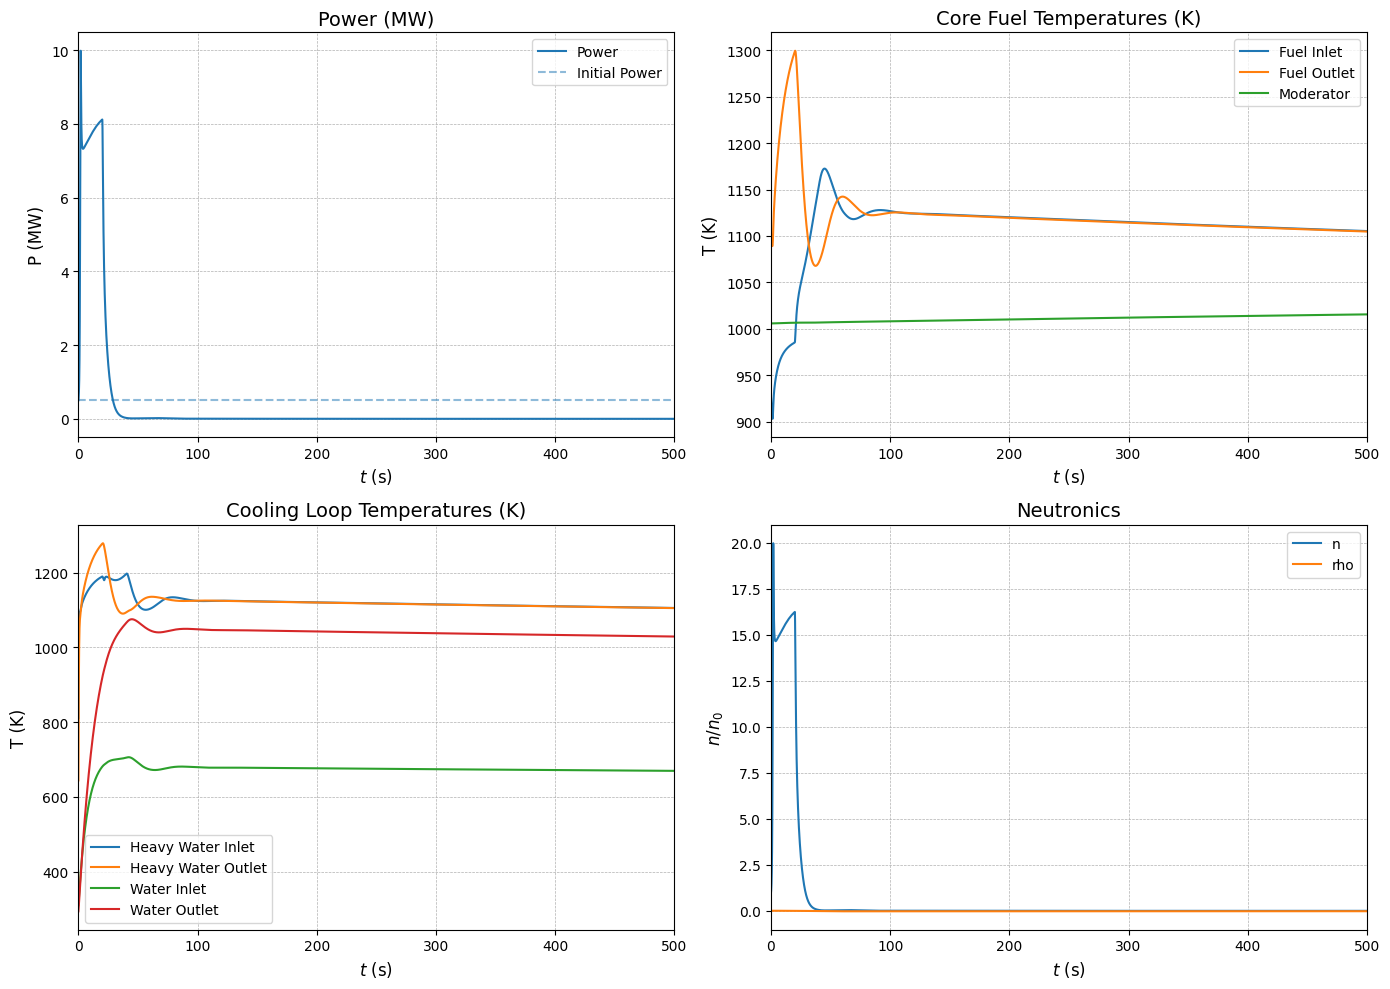

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

t_0 = 0.0
t_f = 500

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

def update_axis_style(ax, title='', x_label='', y_label=''):
    ax.set_xlim([t_0, t_f])
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Power
update_axis_style(axs[0, 0], 'Power (MW)', '$t$ (s)', 'P (MW)')
axs[0, 0].plot(T, P * n.y_out, color=colors[0], label='Power')
axs[0, 0].axhline(y=P, color=colors[0], linestyle='--', alpha=0.5, label='Initial Power')
axs[0, 0].legend()

# Core temperatures
update_axis_style(axs[0, 1], 'Core Fuel Temperatures (K)', '$t$ (s)', 'T (K)')
axs[0, 1].plot(T, c_f1.y_out, label='Fuel Inlet', color=colors[0])
axs[0, 1].plot(T, c_f2.y_out, label='Fuel Outlet', color=colors[1])
axs[0, 1].plot(T, c_m1.y_out, label='Moderator', color=colors[2])
axs[0, 1].legend()

# Heavy water and water temperatures
update_axis_style(axs[1, 0], 'Cooling Loop Temperatures (K)', '$t$ (s)', 'T (K)')
axs[1, 0].plot(T, hw_f1.y_out, label='Heavy Water Inlet', color=colors[0])
axs[1, 0].plot(T, hw_f2.y_out, label='Heavy Water Outlet', color=colors[1])
axs[1, 0].plot(T, w_f1.y_out, label='Water Inlet', color=colors[2])
axs[1, 0].plot(T, w_f2.y_out, label='Water Outlet', color=colors[3])
axs[1, 0].legend()

# Neutronics
update_axis_style(axs[1, 1], 'Neutronics', '$t$ (s)', '$n/n_0$')
axs[1, 1].plot(T, n.y_out, label='n', color=colors[0])
axs[1, 1].plot(T, rho.y_out, label='rho', color=colors[1])
axs[1, 1].legend()

plt.tight_layout()
plt.show()

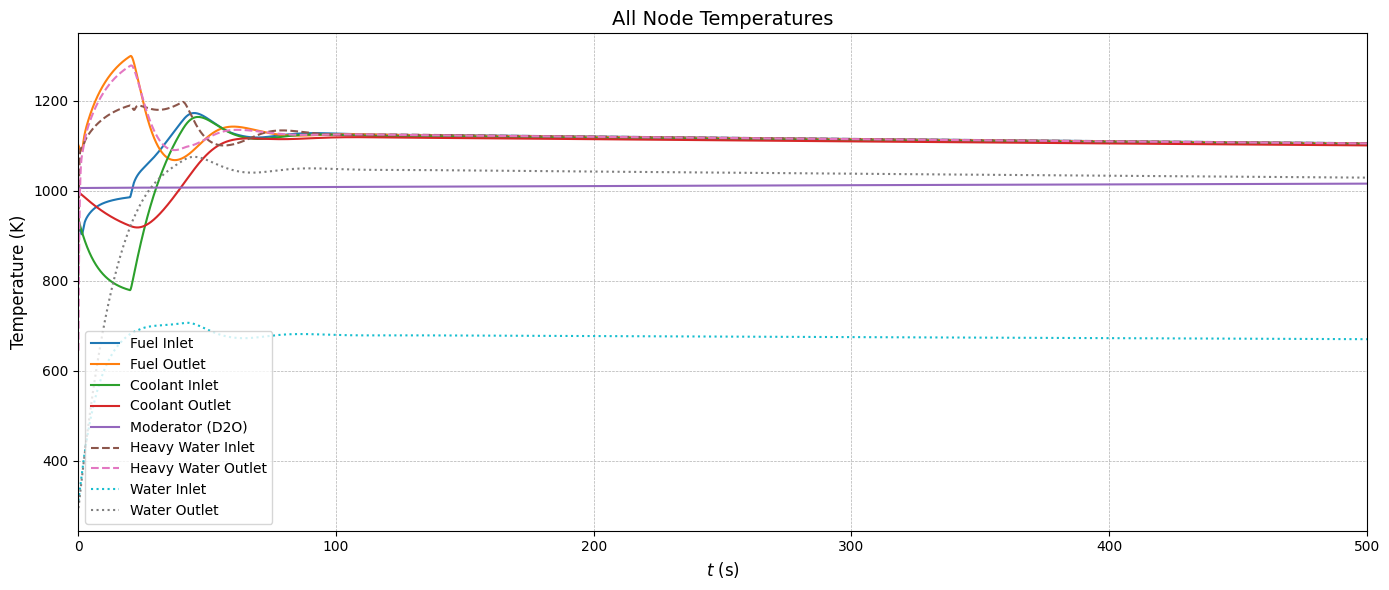

In [9]:
# Additional visualization: All temperatures together
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(T, c_f1.y_out, label='Fuel Inlet', color='tab:blue')
ax.plot(T, c_f2.y_out, label='Fuel Outlet', color='tab:orange')
ax.plot(T, c_c1.y_out, label='Coolant Inlet', color='tab:green')
ax.plot(T, c_c2.y_out, label='Coolant Outlet', color='tab:red')
ax.plot(T, c_m1.y_out, label='Moderator (D2O)', color='tab:purple')
ax.plot(T, hw_f1.y_out, label='Heavy Water Inlet', color='tab:brown', linestyle='--')
ax.plot(T, hw_f2.y_out, label='Heavy Water Outlet', color='tab:pink', linestyle='--')
ax.plot(T, w_f1.y_out, label='Water Inlet', color='tab:cyan', linestyle=':')
ax.plot(T, w_f2.y_out, label='Water Outlet', color='tab:gray', linestyle=':')

ax.set_xlim([0, 500])
ax.set_xlabel('$t$ (s)', fontsize=12)
ax.set_ylabel('Temperature (K)', fontsize=12)
ax.set_title('All Node Temperatures', fontsize=14)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrates a heavy water moderated reactor model with:
- Core fuel and coolant nodes with heat generation
- Heavy water moderator that also transfers heat
- Water cooling loop for the heavy water
- Point kinetics neutronics with thermal feedback
- Time-delayed transport between components